In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#dockerDF = pd.read_csv('../3080-gpuData-docker-trial-0.csv')
dockerDF = pd.read_csv('../a10-gpuData-0.csv')

hostDF = pd.read_csv('../3080-gpuData-host-trial-0.csv')

In [3]:
print(dockerDF.columns)
print(dockerDF.shape)

print(hostDF.columns)
print(hostDF.shape)

Index(['source', 'exePath', 'kernel_executed', 'eteProfilerXtime', 'CC',
       'Kernel Name', 'traffic', 'bytesRead', 'bytesWrite', 'bytesTotal',
       'dpAI', 'spAI', 'hpAI', 'dpPerf', 'spPerf', 'hpPerf', 'xtime',
       'Block Size', 'Grid Size', 'device', 'SP_FLOP', 'DP_FLOP', 'HP_FLOP',
       'INTOP', 'intPerf', 'intAI', 'targetName', 'exeArgs', 'runtime',
       'kernelMangled', 'kernelName', 'kernelDemangled', 'kernelProfiler'],
      dtype='object')
(2462, 33)
Index(['source', 'exePath', 'kernel_executed', 'eteProfilerXtime', 'CC',
       'Kernel Name', 'traffic', 'bytesRead', 'bytesWrite', 'bytesTotal',
       'dpAI', 'spAI', 'hpAI', 'dpPerf', 'spPerf', 'hpPerf', 'xtime',
       'Block Size', 'Grid Size', 'device', 'SP_FLOP', 'DP_FLOP', 'HP_FLOP',
       'INTOP', 'intPerf', 'intAI', 'targetName', 'exeArgs', 'runtime',
       'kernelMangled', 'kernelName', 'kernelDemangled', 'kernelProfiler'],
      dtype='object')
(2487, 33)


In [4]:
# let's drop rows with specific null values in specific columns
dockerDF = dockerDF.dropna(how='any', axis=0, subset=['traffic', 'CC'])
hostDF = hostDF.dropna(how='any', axis=0, subset=['traffic', 'CC'])

print(dockerDF.shape)
print(hostDF.shape)

# drop any rows that don't have a "normal" value for the "kernel_executed" column
dockerDF = dockerDF[dockerDF['kernel_executed'] == 'normal']
hostDF = hostDF[hostDF['kernel_executed'] == 'normal']

print(dockerDF.shape)
print(hostDF.shape)

(1758, 33)
(1816, 33)
(1758, 33)
(1816, 33)


In [5]:
print(hostDF.iloc[0])

source                                                  accuracy-cuda
exePath             /home/gbolet/gpuFLOPBench-updated/build/bin/cu...
kernel_executed                                                normal
eteProfilerXtime                                             2.354131
CC                                                                8.6
Kernel Name                            _Z15accuracy_kerneliiiPKfPKiPi
traffic                                           643281039220.579956
bytesRead                                                 327813632.0
bytesWrite                                                  1793280.0
bytesTotal                                                329606912.0
dpAI                                                              0.0
spAI                                                              0.0
hpAI                                                              0.0
dpPerf                                                            0.0
spPerf              

In [6]:
print(dockerDF.iloc[0])

source                                                  accuracy-cuda
exePath             /lambda/nfs/workspace/gpuFLOPBench-updated/bui...
kernel_executed                                                normal
eteProfilerXtime                                             3.308327
CC                                                                8.6
Kernel Name                            _Z15accuracy_kerneliiiPKfPKiPi
traffic                                           558166017217.939941
bytesRead                                                 392077184.0
bytesWrite                                                  2121984.0
bytesTotal                                                394199168.0
dpAI                                                              0.0
spAI                                                              0.0
hpAI                                                              0.0
dpPerf                                                            0.0
spPerf              

In [7]:
# the "traffic" metric is in the units of bytes/sec, so let's convert it to bytes
# by multiplying by the kernel execution time (xtime) -- need to scale it out of (ns)

dockerDF['trafficBytes'] = dockerDF['traffic'] * dockerDF['xtime'] * 1e-9
hostDF['trafficBytes'] = hostDF['traffic'] * hostDF['xtime'] * 1e-9

In [8]:
# we want to align both dataframes based on the "kernelMangled" and "source" columns
#mergedDF = pd.merge(hostDF, dockerDF, on=['kernelMangled', 'Kernel Name', 'kernelName', 'kernelDemangled', 
#                                          'kernelProfiler', 'targetName', 'CC', 'runtime', 'source', 'exeArgs',
#                                          'device', 'Block Size', 'Grid Size'], suffixes=('_host', '_docker'))

mergedDF = pd.merge(hostDF, dockerDF, on=['kernelMangled', 'Kernel Name', 'kernelName', 'kernelDemangled', 
                                          'kernelProfiler', 'targetName', 'CC', 'runtime', 'source', 'exeArgs',
                                          'Block Size', 'Grid Size'], suffixes=('_3080', '_a10'))

print(mergedDF.columns)
print(mergedDF.shape)

mergedDF.sort_values(by=['targetName', 'source'], ascending=True, inplace=True)

print(mergedDF.head(4))

#print(mergedDF['kernel_executed_docker'].unique())
print(mergedDF['kernel_executed_a10'].unique())

# drop any rows where kernel_executed_host or kernel_executed_docker is NOT "normal"
#mergedDF = mergedDF[(mergedDF['kernel_executed_host'] == 'normal') & (mergedDF['kernel_executed_docker'] == 'normal')]
mergedDF = mergedDF[(mergedDF['kernel_executed_3080'] == 'normal') & (mergedDF['kernel_executed_a10'] == 'normal')]
print(mergedDF.shape)

print(mergedDF.iloc[0])

Index(['source', 'exePath_3080', 'kernel_executed_3080',
       'eteProfilerXtime_3080', 'CC', 'Kernel Name', 'traffic_3080',
       'bytesRead_3080', 'bytesWrite_3080', 'bytesTotal_3080', 'dpAI_3080',
       'spAI_3080', 'hpAI_3080', 'dpPerf_3080', 'spPerf_3080', 'hpPerf_3080',
       'xtime_3080', 'Block Size', 'Grid Size', 'device_3080', 'SP_FLOP_3080',
       'DP_FLOP_3080', 'HP_FLOP_3080', 'INTOP_3080', 'intPerf_3080',
       'intAI_3080', 'targetName', 'exeArgs', 'runtime', 'kernelMangled',
       'kernelName', 'kernelDemangled', 'kernelProfiler', 'trafficBytes_3080',
       'exePath_a10', 'kernel_executed_a10', 'eteProfilerXtime_a10',
       'traffic_a10', 'bytesRead_a10', 'bytesWrite_a10', 'bytesTotal_a10',
       'dpAI_a10', 'spAI_a10', 'hpAI_a10', 'dpPerf_a10', 'spPerf_a10',
       'hpPerf_a10', 'xtime_a10', 'device_a10', 'SP_FLOP_a10', 'DP_FLOP_a10',
       'HP_FLOP_a10', 'INTOP_a10', 'intPerf_a10', 'intAI_a10',
       'trafficBytes_a10'],
      dtype='object')
(1024, 56)
  

In [9]:
cmembench_data = mergedDF[(mergedDF['targetName'] == 'cmembench') & (mergedDF['source'] == 'cmembench-cuda')]

print(cmembench_data.shape)
print(cmembench_data)

(3, 56)
             source                                       exePath_3080  \
190  cmembench-cuda  /home/gbolet/gpuFLOPBench-updated/build/bin/cu...   
191  cmembench-cuda  /home/gbolet/gpuFLOPBench-updated/build/bin/cu...   
192  cmembench-cuda  /home/gbolet/gpuFLOPBench-updated/build/bin/cu...   

    kernel_executed_3080  eteProfilerXtime_3080   CC  \
190               normal              16.307078  8.6   
191               normal              16.307078  8.6   
192               normal              16.307078  8.6   

                           Kernel Name  traffic_3080  bytesRead_3080  \
190      _Z18benchmark_constantIiEvPii    2545685.97          7936.0   
191  _Z18benchmark_constantI4int2EvPii    3270910.10          9216.0   
192  _Z18benchmark_constantI4int4EvPii    2443205.33          7936.0   

     bytesWrite_3080  bytesTotal_3080  ...  hpPerf_a10  xtime_a10  device_a10  \
190            128.0           8064.0  ...         0.0  4882624.0  NVIDIA A10   
191           1152.

['exePath_3080', 'kernel_executed_3080', 'eteProfilerXtime_3080', 'traffic_3080', 'bytesRead_3080', 'bytesWrite_3080', 'bytesTotal_3080', 'dpAI_3080', 'spAI_3080', 'hpAI_3080', 'dpPerf_3080', 'spPerf_3080', 'hpPerf_3080', 'xtime_3080', 'device_3080', 'SP_FLOP_3080', 'DP_FLOP_3080', 'HP_FLOP_3080', 'INTOP_3080', 'intPerf_3080', 'intAI_3080', 'trafficBytes_3080']
['exePath_a10', 'kernel_executed_a10', 'eteProfilerXtime_a10', 'traffic_a10', 'bytesRead_a10', 'bytesWrite_a10', 'bytesTotal_a10', 'dpAI_a10', 'spAI_a10', 'hpAI_a10', 'dpPerf_a10', 'spPerf_a10', 'hpPerf_a10', 'xtime_a10', 'device_a10', 'SP_FLOP_a10', 'DP_FLOP_a10', 'HP_FLOP_a10', 'INTOP_a10', 'intPerf_a10', 'intAI_a10', 'trafficBytes_a10']
['DP_FLOP', 'HP_FLOP', 'INTOP', 'SP_FLOP', 'bytesRead', 'bytesTotal', 'bytesWrite', 'device', 'dpAI', 'dpPerf', 'eteProfilerXtime', 'exePath', 'hpAI', 'hpPerf', 'intAI', 'intPerf', 'kernel_executed', 'spAI', 'spPerf', 'traffic', 'trafficBytes', 'xtime']


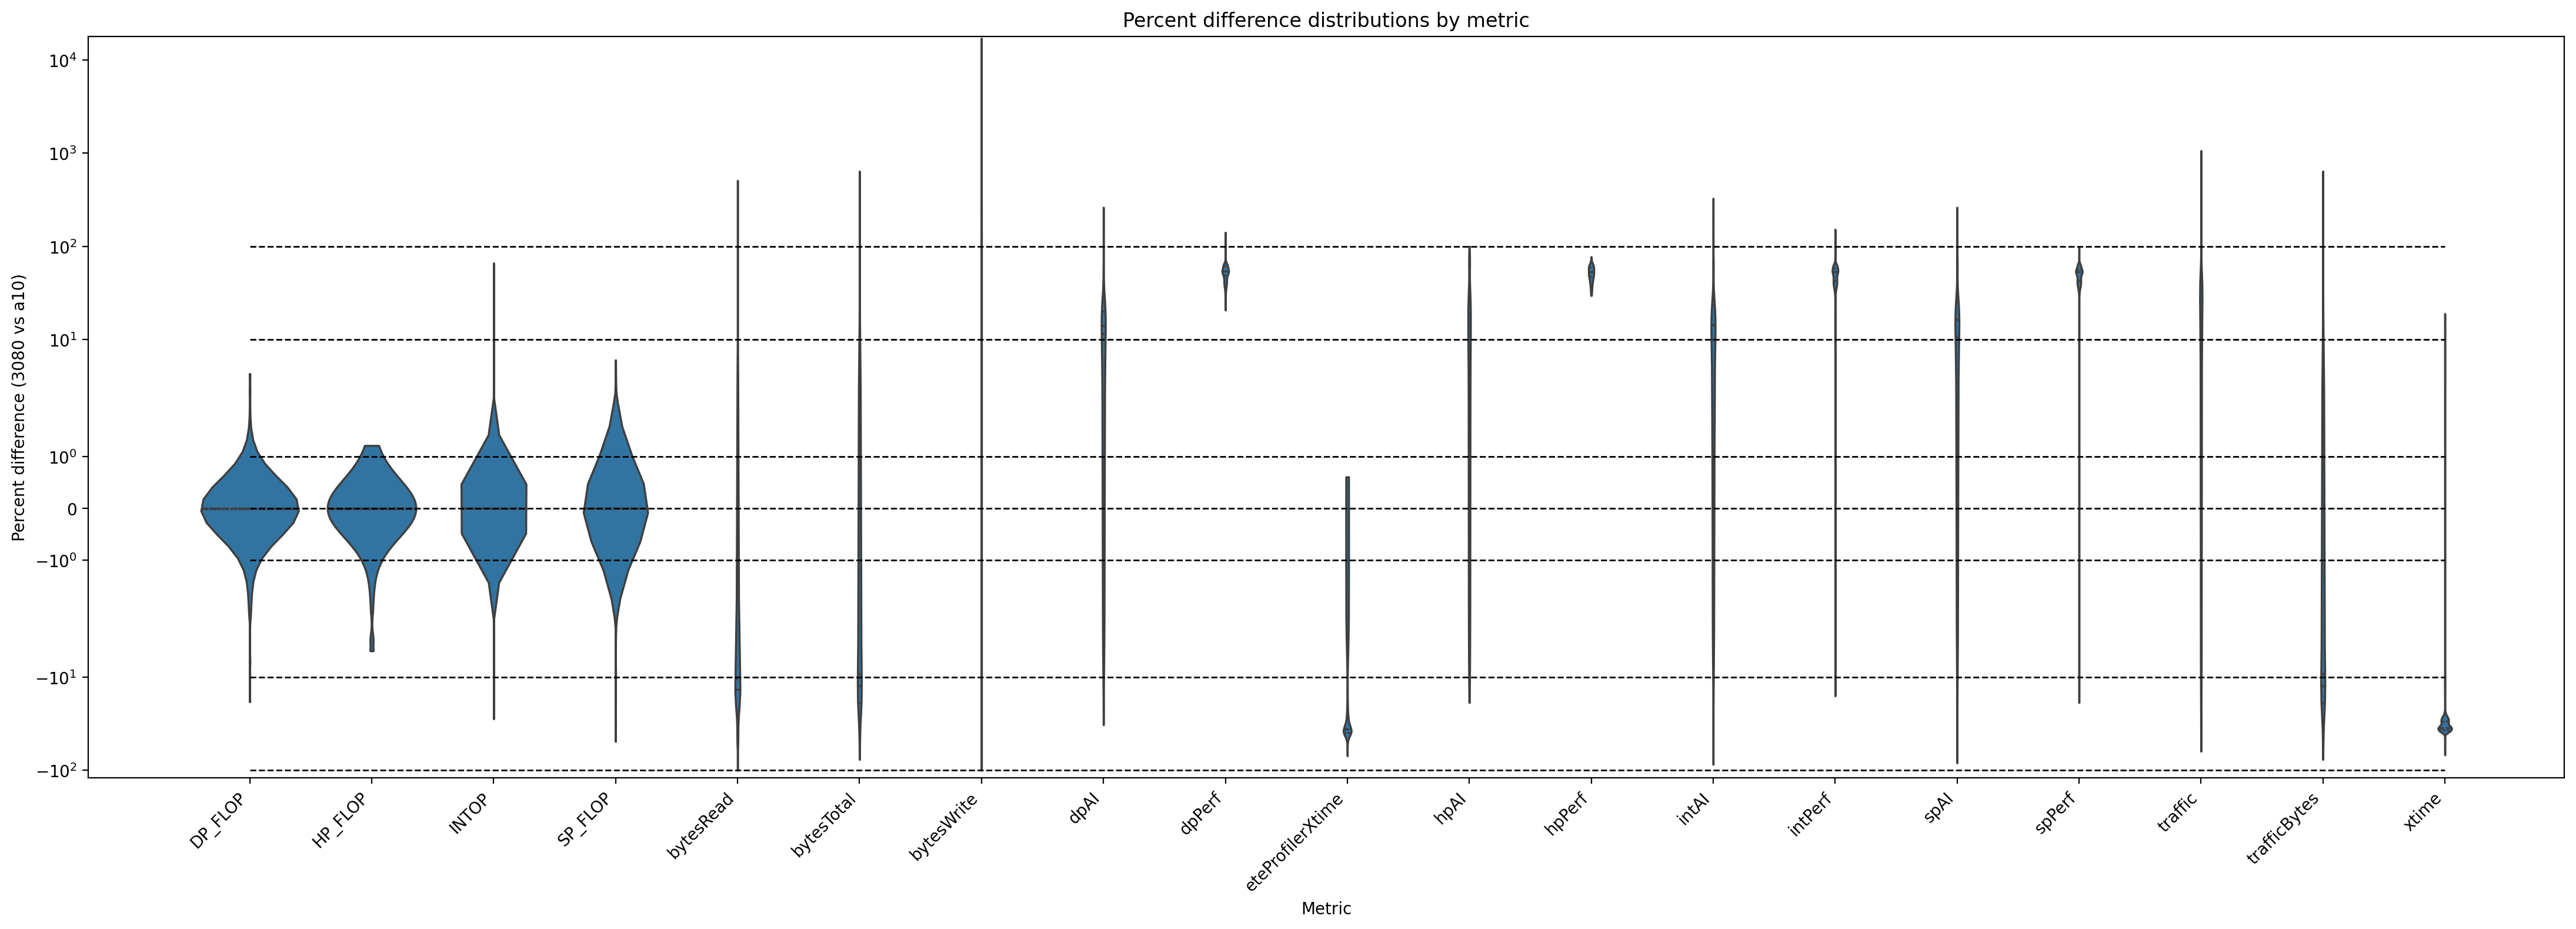

In [10]:
# make violin seaborn plots here

# identify numeric *_host / *_docker pairs
#host_cols = [c for c in mergedDF.columns if c.endswith('_host')]
#docker_cols = [c for c in mergedDF.columns if c.endswith('_docker')]
host_cols = [c for c in mergedDF.columns if c.endswith('_3080')]
docker_cols = [c for c in mergedDF.columns if c.endswith('_a10')]

print(host_cols)
print(docker_cols)

#base_cols = sorted(set(c[:-5] for c in host_cols).intersection(c[:-7] for c in docker_cols))
base_cols = sorted(set(c[:-5] for c in host_cols).intersection(c[:-4] for c in docker_cols))

print(base_cols)

records = []
for base in base_cols:
    #host_col = f"{base}_host"
    #docker_col = f"{base}_docker"
    host_col = f"{base}_3080"
    docker_col = f"{base}_a10"
    if host_col not in mergedDF.columns or docker_col not in mergedDF.columns:
        continue
    # ensure numeric and drop invalid rows
    host_vals = pd.to_numeric(mergedDF[host_col], errors='coerce')
    docker_vals = pd.to_numeric(mergedDF[docker_col], errors='coerce')

    valid = (~host_vals.isna()) & (~docker_vals.isna()) 
    if valid.any():
        pct_diff = (host_vals[valid] - docker_vals[valid]) / docker_vals[valid] * 100.0
        records.append(pd.DataFrame({"metric": base, "pct_diff": pct_diff}))

if not records:
    print("No matching *_host/*_docker numeric columns found for plotting.")
else:
    plot_df = pd.concat(records, ignore_index=True)
    xsize = max(8, len(base_cols))
    plt.figure(figsize=(xsize, 8), dpi=200)
    ax = sns.violinplot(data=plot_df, x="metric", y="pct_diff", inner="quartile", cut=0)
    ax.set_xlabel("Metric")
    #ax.set_ylabel("Percent difference (host vs docker)")
    ax.set_ylabel("Percent difference (3080 vs a10)")
    ax.set_title("Percent difference distributions by metric")

    ax.set_yscale("symlog")
    ax.set_ylim(bottom=-120)

    ax.hlines(y=[0, -1, 1, -10, 10, -100, 100], xmin=0, xmax=plot_df['metric'].nunique()-1, color='black', linestyle='--', linewidth=1)

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [11]:
# build a detailed dataframe for largest percent differences
detail_records = []
for base in base_cols:
    host_col = f"{base}_host"
    docker_col = f"{base}_docker"
    if host_col not in mergedDF.columns or docker_col not in mergedDF.columns:
        continue
    host_vals = pd.to_numeric(mergedDF[host_col], errors="coerce")
    docker_vals = pd.to_numeric(mergedDF[docker_col], errors="coerce")
    valid = (~host_vals.isna()) & (~docker_vals.isna())
    if not valid.any():
        continue
    pct = (host_vals[valid] - docker_vals[valid]) / docker_vals[valid] * 100.0
    temp = pd.DataFrame({
        "metric": base,
        "source": mergedDF.loc[valid, "source"].values,
        "targetName": mergedDF.loc[valid, "targetName"].values,
        "Kernel Name": mergedDF.loc[valid, "Kernel Name"].values,
        "Block Size": mergedDF.loc[valid, "Block Size"].values,
        "Grid Size": mergedDF.loc[valid, "Grid Size"].values,
        "host_value": host_vals[valid].values,
        "docker_value": docker_vals[valid].values,
        "pct_diff": pct.values,
    })
    detail_records.append(temp)

if not detail_records:
    print("No detailed percent-difference records to inspect.")
else:
    diff_df = pd.concat(detail_records, ignore_index=True)
    diff_df = diff_df.replace([np.inf, -np.inf], np.nan)
    diff_df = diff_df.dropna(subset=["pct_diff"])
    diff_df["abs_pct_diff"] = diff_df["pct_diff"].abs()
    diff_df = diff_df.sort_values("abs_pct_diff", ascending=False)

    print("Largest percent differences (host vs docker):")
    print(diff_df.head(100)[["metric", "source", "targetName", 
                             "Kernel Name", "Block Size", "Grid Size",
                             "host_value", "docker_value", 
                             "pct_diff"]].to_string(index=False))

No detailed percent-difference records to inspect.


In [13]:
# although the "traffic" metric and "intAI" metric differ a lot for atomicPerf-cuda on the "_Z28SingleRangeAtomicOnSharedMemIdEvPT_ii" kernel,
# it is doing <double> operations, and that's what we care about. The amount of work, given the block and grid size doesn't seem too small,
# so it might not be "noise". Let's look at the DPFLOPs to see if those differ too.

atomicPerfCuda_data = mergedDF[(mergedDF['targetName'] == 'atomicPerf') & (mergedDF['source'] == 'atomicPerf-cuda') & (mergedDF['Kernel Name'] == '_Z28SingleRangeAtomicOnSharedMemIdEvPT_ii')]

print(atomicPerfCuda_data.shape)

#print(atomicPerfCuda_data[['DP_FLOP_host', 'DP_FLOP_docker', 'intAI_host', 'intAI_docker', 'trafficBytes_host', 'trafficBytes_docker']])
print(atomicPerfCuda_data[['DP_FLOP_3080', 'DP_FLOP_a10', 'intAI_3080', 'intAI_a10', 'trafficBytes_3080', 'trafficBytes_a10']])

# print the DP_FLOP percent difference for this kernel
#host_dpflop = pd.to_numeric(atomicPerfCuda_data['DP_FLOP_host'], errors='coerce')
#docker_dpflop = pd.to_numeric(atomicPerfCuda_data['DP_FLOP_docker'], errors='coerce')   
host_dpflop = pd.to_numeric(atomicPerfCuda_data['DP_FLOP_3080'], errors='coerce')
docker_dpflop = pd.to_numeric(atomicPerfCuda_data['DP_FLOP_a10'], errors='coerce')   
pct_dpflop = (host_dpflop - docker_dpflop) / docker_dpflop * 100.0
print("DP_FLOP percent difference (host vs docker):")
print(pct_dpflop)

# what we can see if that the percent difference in DP_FLOP is small (~0.03%), indicating that the actual work done is similar,
# even though the "intAI" and "traffic" metrics differ significantly. 

(1, 56)
    DP_FLOP_3080  DP_FLOP_a10    intAI_3080     intAI_a10  trafficBytes_3080  \
80   118212134.0  118867392.0  50518.472905  71477.483284        4863.999996   

    trafficBytes_a10  
80       3455.999997  
DP_FLOP percent difference (host vs docker):
80   -0.551251
dtype: float64
